# Chapter 12 부록 — 데이터 스케일링: BERT vs sklearn 곡선

**환경**: Google Colab **T4 GPU 필수**.

본편 Ch 12 는 **5,000 샘플 한 점** 에서 DistilBERT(0.577) 가 sklearn TF-IDF(0.542) 를 *근소하게만* 앞섰습니다. 670배 큰 파라미터에 비하면 격차가 작은데, 이게 **데이터가 적어서** 인지 **5클래스 task 자체가 어려워서** 인지는 한 점만 봐선 알 수 없습니다.

이 부록은 **train size 를 100 → 30,000 으로 키우며** 두 모델의 정확도 곡선을 나란히 그립니다. 어디서 곡선이 교차하고, 어디서 격차가 벌어지는지가 핵심 학습 포인트입니다.

**공정 비교 3원칙:**
1. **eval 셋 고정** — 평가 셋은 1,000 으로 한 번 잡고 *학습 size 만* 바꿉니다.
2. **nested subsample (같은 seed)** — `pool.select(range(N))` 로 size-N 이 size-3N 의 *부분집합* 이 되게. "데이터 추가 = 기존 + 새 샘플".
3. **epoch 고정(2)** — 데이터 늘리면서 epoch 까지 늘리면 *데이터 효과* 와 *compute 효과* 가 섞입니다. 순수 데이터 스케일링을 보려고 epoch=2 고정.

> ⚠️ **sklearn 설정이 본편 §5 와 다릅니다.** 이 부록은 `TfidfVectorizer()` 기본값(feature 수 제한 없음·unigram)을 쓰고, 본편 §5 는 `max_features=20000, ngram_range=(1, 2)` 를 씁니다. 부록의 관심사는 *한 설정을 고정해 두고 데이터 양만 바꿨을 때의 추세* 이므로 절대 좌표를 본편과 직접 맞대어 읽지 마세요. 본편 한 점은 이 곡선 *위의 점* 이 아니라 *같은 추세대의 별도 측정* 입니다.

> BERT 는 size 마다 같은 초기화(seed 고정)에서 출발합니다.

In [1]:
!pip install -q transformers datasets

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

assert torch.cuda.is_available(), (
    "GPU 런타임이 아닙니다. 런타임 → 런타임 유형 변경 → T4 GPU 로 바꾼 뒤 다시 실행하세요. "
    "CPU 로는 이 부록이 16시간 이상 걸려 사실상 완주할 수 없습니다."
)

# matplotlib 한글 폰트 (Colab — NanumGothic). plot 의 한국어가 □ 로 깨지지 않게.
import matplotlib.pyplot as plt, matplotlib.font_manager as fm, subprocess, os
_fp = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if not os.path.exists(_fp):
    subprocess.run("apt-get -qq -y install fonts-nanum", shell=True)
fm.fontManager.addfont(_fp)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
print(f"PyTorch: {torch.__version__}  CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available(): print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cu128  CUDA: True
GPU: Tesla T4


## 1. 데이터 — 학습 pool(최대 30K) + 고정 eval(1K)

`pool` 을 30,000 으로 한 번 셔플해 두고, size-N 학습 셋은 `pool.select(range(N))` 로 *앞에서부터* 잘라 nested 가 되게 합니다. eval 은 별도 1,000 으로 고정합니다 (본편 Ch 12 와 같은 split·seed).

In [3]:
MAX_N = 30000
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
ds = load_dataset("Yelp/yelp_review_full")
pool      = ds["train"].shuffle(seed=42).select(range(MAX_N))   # nested subsample 원천
eval_full = ds["test"].shuffle(seed=42).select(range(1000))     # 고정 eval

def tok_fn(batch):
    out = tokenizer(batch["text"], truncation=True, max_length=128)
    out["labels"] = [int(l) for l in batch["label"]]
    return out

eval_tok = eval_full.map(tok_fn, batched=True).remove_columns(["text", "label"])
eval_texts = eval_full["text"]; eval_y = np.array(eval_full["label"])
print(f"pool: {len(pool)}, eval: {len(eval_full)}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

README.md:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

...

yelp_review_full/test-00000-of-00001.par(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

pool: 30000, eval: 1000


## 2. 학습 함수 — BERT / sklearn

`train_bert(N)` 은 size-N 부분집합으로 DistilBERT 5클래스를 epoch 2 학습하고 고정 eval 정확도를 돌려줍니다(매번 seed 42 동일 초기화). `train_sklearn(N)` 은 같은 부분집합으로 TF-IDF + LogReg 를 학습합니다.

In [4]:
def accuracy_metric(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {"accuracy": float(accuracy_score(labels, preds))}

def train_bert(N, epochs=2):
    sub = pool.select(range(N))
    sub_tok = sub.map(tok_fn, batched=True).remove_columns(["text", "label"])
    torch.manual_seed(42); np.random.seed(42)   # size 마다 동일 초기화
    model = AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", num_labels=5,
        problem_type="single_label_classification",
    )
    args = TrainingArguments(
        output_dir=f"./bert_{N}", num_train_epochs=epochs,
        per_device_train_batch_size=16, per_device_eval_batch_size=32,
        learning_rate=2e-5, fp16=True, eval_strategy="no",
        logging_steps=200, save_strategy="no", report_to="none", seed=42,
    )
    tr = Trainer(model=model, args=args, train_dataset=sub_tok, eval_dataset=eval_tok,
                 processing_class=tokenizer, compute_metrics=accuracy_metric)
    tr.train()
    acc = float(tr.evaluate()["eval_accuracy"])
    del model, tr; torch.cuda.empty_cache()
    return acc

def train_sklearn(N):
    sub = pool.select(range(N))
    vec = TfidfVectorizer()
    Xtr = vec.fit_transform(sub["text"]); ytr = np.array(sub["label"])
    clf = LogisticRegression(max_iter=1000)
    clf.fit(Xtr, ytr)
    Xev = vec.transform(eval_texts)
    return float(accuracy_score(eval_y, clf.predict(Xev)))
print("학습 함수 준비 완료")

학습 함수 준비 완료


## 3. 스윕 — train size 그리드

`N ∈ {100, 300, 1000, 3000, 10000, 30000}` 각각에서 두 모델을 학습해 고정 eval 정확도를 기록합니다. (BERT 30K 학습이 가장 오래)

In [5]:
GRID = [100, 300, 1000, 3000, 10000, 30000]
rows = []
for N in GRID:
    sk = train_sklearn(N)
    bert = train_bert(N)
    rows.append({"train_size": N, "sklearn_acc": sk, "bert_acc": bert, "gap": bert - sk})
    print(f"N={N:>6}: sklearn={sk:.4f}  BERT={bert:.4f}  gap={bert - sk:+.4f}")
res = pd.DataFrame(rows)
print(); print(res.round(4).to_string(index=False))

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
200,1.304225
400,1.090725
600,1.067562
800,1.064483
1000,1.009315
1200,1.000513
1400,0.975254
1600,0.974570
1800,0.967793
2000,0.858166


Training Loss,Validation Loss,Step,Accuracy
0.811135,0.906982,3750,0.600000


N= 30000: sklearn=0.5630  BERT=0.6000  gap=+0.0370

 train_size  sklearn_acc  bert_acc    gap
        100        0.373     0.229 -0.144
        300        0.396     0.262 -0.134
       1000        0.471     0.500  0.029
       3000        0.524     0.557  0.033
      10000        0.569     0.588  0.019
      30000        0.563     0.600  0.037


## 4. 곡선 — 정확도 vs 학습 데이터 양

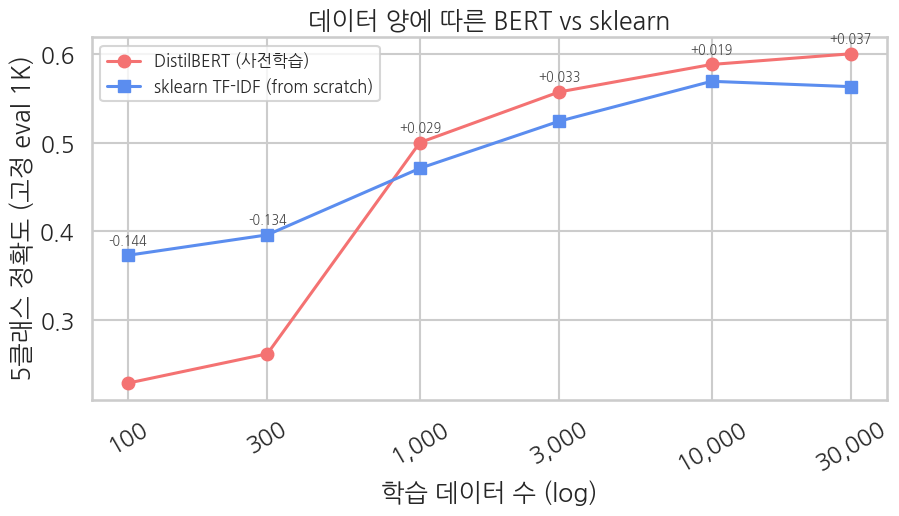

본편(5,000) 한 점: 부록 그리드엔 5K 미포함 — 가장 가까운 3K/10K 로 추세 확인
가장 작은 데이터(N=100): sklearn=0.3730  BERT=0.2290  gap=-0.1440
가장 큰 데이터 (N=30000): sklearn=0.5630  BERT=0.6000  gap=+0.0370


In [6]:
sns.set_theme(style="whitegrid", context="talk", font="NanumGothic", rc={"axes.unicode_minus": False})
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.plot(res["train_size"], res["bert_acc"], "o-", color="#F47272", lw=2.2, ms=9, label="DistilBERT (사전학습)")
ax.plot(res["train_size"], res["sklearn_acc"], "s-", color="#5B8DEF", lw=2.2, ms=9, label="sklearn TF-IDF (from scratch)")
ax.set_xscale("log")
ax.set_xlabel("학습 데이터 수 (log)")
ax.set_ylabel("5클래스 정확도 (고정 eval 1K)")
ax.set_title("데이터 양에 따른 BERT vs sklearn")
ax.set_xticks(res["train_size"])
ax.set_xticklabels([f"{n:,}" for n in res["train_size"]], rotation=30)
ax.legend(fontsize=12)
for _, r in res.iterrows():
    ax.annotate(f"{r['gap']:+.3f}", (r["train_size"], max(r["bert_acc"], r["sklearn_acc"]) + 0.012),
                ha="center", fontsize=9, color="#444")
plt.tight_layout(); plt.show()

sk5  = float(res.loc[res["train_size"]==5000, "sklearn_acc"].iloc[0]) if 5000 in GRID else None
print("본편(5,000) 한 점:", "부록 그리드엔 5K 미포함 — 가장 가까운 3K/10K 로 추세 확인" if sk5 is None else sk5)
print(f"가장 작은 데이터(N={GRID[0]}): sklearn={res['sklearn_acc'].iloc[0]:.4f}  BERT={res['bert_acc'].iloc[0]:.4f}  gap={res['gap'].iloc[0]:+.4f}")
print(f"가장 큰 데이터 (N={GRID[-1]}): sklearn={res['sklearn_acc'].iloc[-1]:.4f}  BERT={res['bert_acc'].iloc[-1]:.4f}  gap={res['gap'].iloc[-1]:+.4f}")

## 5. 해석

곡선이 **두 번 이야기** 합니다.

**작은 데이터(N=100-300): sklearn 이 크게 앞섭니다 (BERT 가 -0.14).** DistilBERT 는 6,700만 파라미터를 100-300 샘플·2 epoch 로 적응시키기엔 데이터가 턱없이 부족해 분류 헤드가 거의 학습되지 않습니다 (N=100 에서 0.229 — 5클래스 random 0.20 바로 위). 반면 TF-IDF + LogReg 는 100 샘플에서도 단어 빈도 신호를 곧장 뽑아 0.373 을 냅니다. **큰 모델이 항상 이기는 게 아니라, 적응할 데이터가 있어야** 이깁니다.

**교차점은 N≈1,000.** 여기서 BERT 가 sklearn 을 추월하고(0.500 vs 0.471), 이후 줄곧 앞섭니다.

**큰 데이터(1K-30K): BERT 가 앞서지만 격차는 완만합니다 (+0.02-0.04).** sklearn 은 ~10K 부터 0.56-0.57 로 평탄해지고, BERT 는 30K 에서 0.600 까지 천천히 오릅니다. **30K 까지 키워도 격차가 +0.037 에 머문다** 는 건, 본편의 근소한 격차가 *데이터 부족만의 문제가 아니라* 5클래스 별점 분류 자체가 어렵다(인접 별점 경계가 모호한 ordinal task)는 뜻입니다 — 이진(Ch 10, BERT 0.90)에서 BERT 가 압도하던 것과 대조적입니다.

| N | sklearn | BERT | gap |
|---|---|---|---|
| 100 | 0.373 | 0.229 | -0.144 |
| 300 | 0.396 | 0.262 | -0.134 |
| 1,000 | 0.471 | 0.500 | +0.029 |
| 3,000 | 0.524 | 0.557 | +0.033 |
| 10,000 | 0.569 | 0.588 | +0.019 |
| 30,000 | 0.563 | 0.600 | +0.037 |

**본편(5,000) 한 점** 은 이 곡선의 1K-10K 구간 — BERT 가 막 앞서기 시작하지만 격차가 작은 자리 — 과 **같은 추세대** 에 놓입니다. 다만 위에서 짚었듯 본편 §5 의 sklearn 은 20K + bigram, 여기는 `TfidfVectorizer()` 기본값이라 **정확히 같은 곡선 위의 점은 아닙니다.** 두 실험이 공유하는 결론은 좌표가 아니라 *교차점의 위치와 그 위에서 격차가 완만하다는 추세* 입니다.

즉 본편의 '근소 우위'는 버그가 아니라 *이 task·이 데이터 규모에서 정상* 입니다. 데이터를 더 부으면 BERT 가 더 벌리지만(우상향), 5클래스가 본질적으로 어려워 이진만큼 극적이진 않습니다.

## 6. 보너스 — BERT 성능을 끌어올리는 5가지 lever

데이터는 가장 큰 lever 중 하나일 뿐입니다. 실무에서 분류 정확도를 더 올리고 싶을 때 순서대로 검토하는 카드:

| lever | 방법 | 대략 효과 |
|---|---|---|
| **1. 데이터 (양 + 질)** | train size↑, 도메인 적응 사전학습(DAPT), 라벨 노이즈 정리 | **+3-15%p** (보통 가장 큼) |
| **2. 더 강한 모델** | DistilBERT → RoBERTa-large / DeBERTa-v3-large | +2-5%p |
| **3. HPO** | learning rate · warmup · weight decay 튜닝 | +1-3%p |
| **4. 학습 전략** | layer-wise LR decay(LLRD), 앙상블 | 각 +1-2%p |
| **5. LLM 라벨링 + distill** | 큰 LLM 으로 라벨 생성 → 작은 모델 증류 (2024-2025 트렌드) | +3-10%p |

이 부록은 그중 **1번(데이터 양)** 을 곡선으로 분리해 본 것입니다. 5클래스에서 본편의 근소한 격차가 *데이터 부족* 때문이라면 곡선이 우상향하며 벌어지고, *task 난이도* 때문이라면 큰 데이터에서도 격차가 평탄할 것입니다 — 위 §4 곡선이 그 답입니다.